Piezo Step Peak Time: [0.000538 0.000608 0.000682 0.000761 0.000802 0.000848 0.000918 0.000958
 0.001003]
Contact Peak Time: [0.000857 0.000939 0.001036 0.001118 0.001221 0.001317 0.001413 0.001494
 0.001576 0.001678 0.001784 0.001864 0.001969 0.002055 0.002159 0.002241
 0.00232  0.0024   0.00249 ]


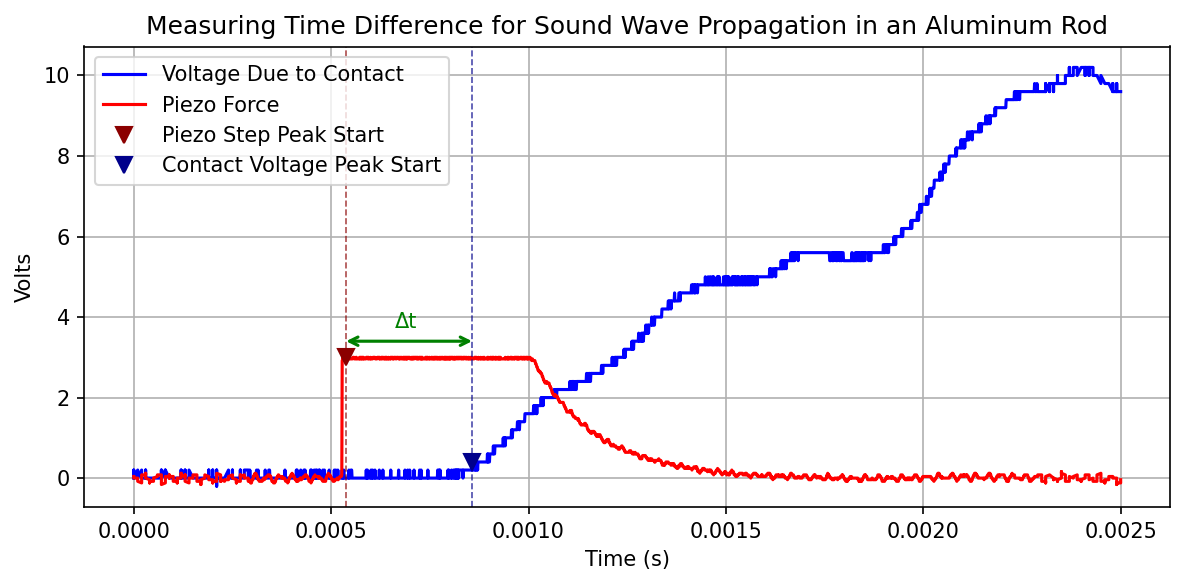

time: 0.00031899999999999995 s


In [58]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.signal as signal
from scipy.signal import find_peaks
import scipy.io as sio

path = "/content/lab2aluminumdata.csv"
data = np.genfromtxt(path, delimiter=',', names='time, voltage, piezo')

t = data['time'] + 0.00129 #adjusting for trigger point time for both data sets
voltage = data['voltage']
piezo = data['piezo']

fig, ax = plt.subplots(figsize=(8,4), dpi=150)

ax.plot(t, voltage, color='blue', label="Voltage Due to Contact")
ax.plot(t, piezo, color='red', label="Piezo Force")

peaks, properties = find_peaks(piezo, height=2.9, distance=40) # same for both metals
print("Piezo Step Peak Time:", t[peaks])

contact_peak, properties = find_peaks(voltage, height=0.201, distance=80) #height of 0.06 for copper and 0.201 for aluminum; distance of 50 for copper and 80 for aluminum
print("Contact Peak Time:", t[contact_peak])

ax.plot(t[peaks[0]], piezo[peaks[0]], "v", color='darkred', markersize=8, label="Piezo Step Peak Start")
ax.plot(t[contact_peak[0]], voltage[contact_peak[0]], "v", color='darkblue', markersize=8, label="Contact Voltage Peak Start")
ax.axvline(t[peaks[0]], color='darkred', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(t[contact_peak[0]], color='darkblue', linestyle='--', linewidth=0.8, alpha=0.7)

t1 = t[peaks[0]]
t2 = t[contact_peak[0]]
y_mid = (piezo[peaks[0]] + voltage[contact_peak[0]])

ax.annotate('', xy=(t2, y_mid), xytext=(t1, y_mid), arrowprops=dict(arrowstyle='<->', color='green', lw=1.5, shrinkA=0, shrinkB=0))

ax.annotate('Δt', xy=(((t1+t2)/2 - 0.000035), (y_mid*1.1)),color='green', arrowprops=None)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Volts')
ax.set_title('Measuring Time Difference for Sound Wave Propagation in an Aluminum Rod')
ax.grid()
fig.tight_layout()
plt.legend()
plt.show()

deltat = (t2 - t1)
print("time:", deltat, "s")